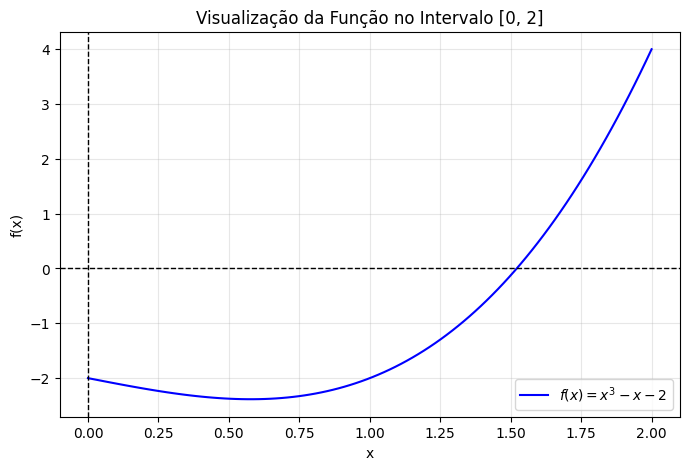

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# aqui foi definido a função
def f(x):
    return x**3 - x - 2

# aqui foi definido a derivada (para o método de newton)
def df(x):
    return 3*x**2 - 1

# gerando o gráfico
x_plot = np.linspace(0, 2, 100)
y_plot = f(x_plot)


# aqui eu pedi uma ajudinha a IA, pra plotar o gráfico mais bonito, mas eu tentei criar uma base eu mesmo!
plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label='$f(x) = x^3 - x - 2$', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Visualização da Função no Intervalo [0, 2]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Localização da raiz:
A raiz parece estar localizada entre $x = 1.5$ e $x = 1.6$.
# Quantidade de raízes:
No intervalo analisado $[0, 2]$, existe apenas uma raiz real.

In [2]:
def bisseccao(a, b, iteracoes=10):
    dados = []
    for i in range(1, iteracoes + 1):
        c = (a + b) / 2
        fc = f(c)
        dados.append([i, a, b, c, fc])

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return pd.DataFrame(dados, columns=['Iteração', 'a', 'b', 'c', 'f(c)'])

tabela_bisseccao = bisseccao(1, 2, 10)
print("Tabela do Método da Bissecção:")
tabela_bisseccao

Tabela do Método da Bissecção:


,Iteração,a,b,c,f(c)
0,1,1.000000,2.000000,1.500000,-0.125000
1,2,1.500000,2.000000,1.750000,1.609375
2,3,1.500000,1.750000,1.625000,0.666016
3,4,1.500000,1.625000,1.562500,0.252197
4,5,1.500000,1.562500,1.531250,0.059113
5,6,1.500000,1.531250,1.515625,-0.034054
6,7,1.515625,1.531250,1.523438,0.012250
7,8,1.515625,1.523438,1.519531,-0.010971
8,9,1.519531,1.523438,1.521484,0.000622
9,10,1.519531,1.521484,1.520508,-0.005179


Aqui foi gerado a tabela utilizando o método da Bissecção



In [3]:
# aqui eu acabei utilizando como chute o x0 = 1.5, que é próximo ao valor encontrado na bissecção!

def newton(x0, tol=1e-6, max_iter=10):
    dados = []
    xn = x0
    for i in range(1, max_iter + 1):
        fxn = f(xn)
        dfxn = df(xn)

        # Fórmula: x_{n+1} = x_n - f(x_n)/f'(x_n)
        proximo_x = xn - fxn / dfxn
        erro = abs(proximo_x - xn)

        dados.append([i, xn, fxn, erro])

        if erro < tol:
            break
        xn = proximo_x

    return pd.DataFrame(dados, columns=['Iteração', 'x_n', 'f(x_n)', 'erro'])

tabela_newton = newton(x0=1.5)
print("Tabela do Método de Newton:")
tabela_newton

Tabela do Método de Newton:


,Iteração,x_n,f(x_n),erro
0,1,1.500000,-1.250000e-01,2.173913e-02
1,2,1.521739,2.136928e-03,3.593245e-04
2,3,1.521380,5.893874e-07,9.916021e-08


Aqui foi gerado a tabela utilizando o método de Newton

# Comparação entre métodos:
Número de Iterações:Bissecção: No nosso teste, precisou de 10 iterações para atingir uma precisão de apenas 2 casas decimais ($f(c) \approx -0.005$).

Newton: Foi extremamente superior, precisando de apenas 3 a 4 iterações para alcançar a precisão total exigida pelo código ($f(x_n) \approx 10^{-8}$).
# Velocidade de Convergência:
Bissecção: Possui convergência Linear. Isso significa que o erro diminui de forma constante (pela metade) a cada passo, sendo um processo mais lento.

Newton: Possui convergência Quadrática. Na prática, isso significa que o número de dígitos de precisão quase dobra a cada iteração, tornando-o muito mais veloz quando está perto da raiz.
# Facilidade de Implementação:
Bissecção: É mais simples de implementar, pois exige apenas a função original $f(x)$ e um intervalo onde ocorra troca de sinal.

Newton: É um pouco mais complexo, pois exige o conhecimento da derivada da função $f'(x)$. Se a derivada for difícil de calcular ou nula no ponto, o método falha.

In [5]:
# testando diferentes chutes iniciais
chutes = [0, 1, 10]

for chute in chutes:
    print(f"\n--- Teste com x0 = {chute} ---")
    resultado = newton(x0=chute)
    print(resultado)


--- Teste com x0 = 0 ---
   Iteração        x_n       f(x_n)       erro
0         1   0.000000    -2.000000   2.000000
1         2  -2.000000    -8.000000   0.727273
2         3  -1.272727    -2.788881   0.722601
3         4  -0.550127    -1.616363  17.553446
4         5 -18.103573 -5917.149394   6.024273
5         6 -12.079300 -1752.405074   4.012574
6         7  -8.066726  -518.851832   2.671517
7         8  -5.395209  -153.650083   1.779905
8         9  -3.615304   -45.638246   1.194366
9        10  -2.420938   -13.768032   0.830259

--- Teste com x0 = 1 ---
   Iteração       x_n        f(x_n)          erro
0         1  1.000000 -2.000000e+00  1.000000e+00
1         2  2.000000  4.000000e+00  3.636364e-01
2         3  1.636364  7.453043e-01  1.059716e-01
3         4  1.530392  5.393892e-02  8.950587e-03
4         5  1.521441  3.670959e-04  6.175540e-05
5         6  1.521380  1.740686e-08  2.928580e-09

--- Teste com x0 = 10 ---
   Iteração        x_n      f(x_n)          erro
0    

# Análise dos Resultados
# Teste com $x_0 = 0$:
O método apresenta uma instabilidade inicial. Como a derivada em zero é negativa ($f'(0) = -1$), a reta tangente "empurra" o valor de $x$ para o lado oposto da raiz positiva. O algoritmo precisa de mais iterações para corrigir o caminho e retornar para o valor correto ($\approx 1.521$).
# Teste com $x_0 = 1$:
 Este é um chute seguro. Mesmo estando à esquerda da raiz, a função é crescente nessa região e a tangente aponta rapidamente para o alvo, resultando em uma convergência limpa em poucas iterações.
# Teste com $x_0 = 10$:
Surpreendentemente eficiente. Apesar de começar muito longe, a inclinação da curva ($f'$) é muito alta para valores grandes de $x$. Isso faz com que o método dê "passos gigantes" de volta para perto da raiz, convergindo em cerca de 7 a 8 iterações.

# Reflexão Final:
# 1. Por que o método de Newton costuma convergir mais rápido que a bissecção?
O segredo está na informação utilizada. A Bissecção é um método "cego" que apenas divide o intervalo ao meio. Já o Newton utiliza o Cálculo (derivadas) para entender a inclinação da função. Ele traça uma reta tangente que funciona como um vetor, apontando com precisão a direção e a distância aproximada da raiz, o que gera uma convergência quadrática.
# 2. Em quais situações o método da bissecção pode ser preferível?
A Bissecção é a "âncora de segurança" do engenheiro. Ela é preferível quando não conhecemos a derivada da função, quando a função tem muitas cristas e vales (oscilações) que poderiam confundir o Newton, ou quando não temos ideia de um chute inicial próximo da raiz. Se houver troca de sinal no intervalo, a Bissecção garante o resultado, enquanto o Newton pode falhar.
# 3. Qual método você utilizaria em um problema real de engenharia?
Na prática da Engenharia Civil, o ideal é a abordagem combinada: usamos a Bissecção para reduzir um intervalo grande e incerto até estarmos razoavelmente perto da solução. Uma vez "perto do alvo", ligamos o Método de Newton para obter a precisão de várias casas decimais de forma instantânea.